In [176]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import scipy.stats as stats
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import importlib
import scipy.constants as sc

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

<module 'SPM_eqs' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/SPM_eqs.py'>

In [102]:
sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
#sol, model,params = sim_PyBaMM.simulate(0.1)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

## Testing the OCV from the `SPM_eqs.py`file compared to `pPyBaMM`output

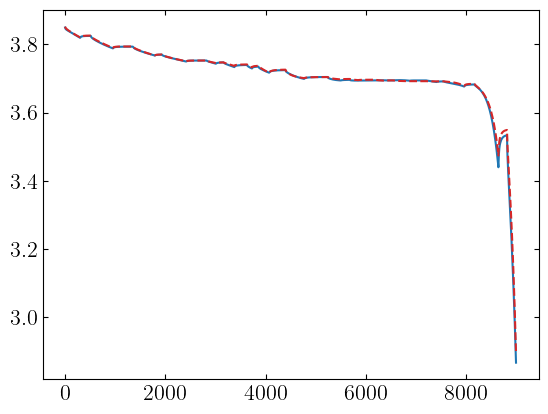

In [115]:
plt.plot(t,SPM_eqs.OCV(cn,cp),color = 'tab:blue')
plt.plot(t,OCV_true,color ='tab:red',ls = '--')


## Testing $\eta_r$ from the `SPM_eqs.py`file compared to `pPyBaMM`output
That apparently didn't work, so testing the $j_{k,0}$ expression

<function lico2_electrolyte_exchange_current_density_Dualfoil1998 at 0x164e3c4a0>


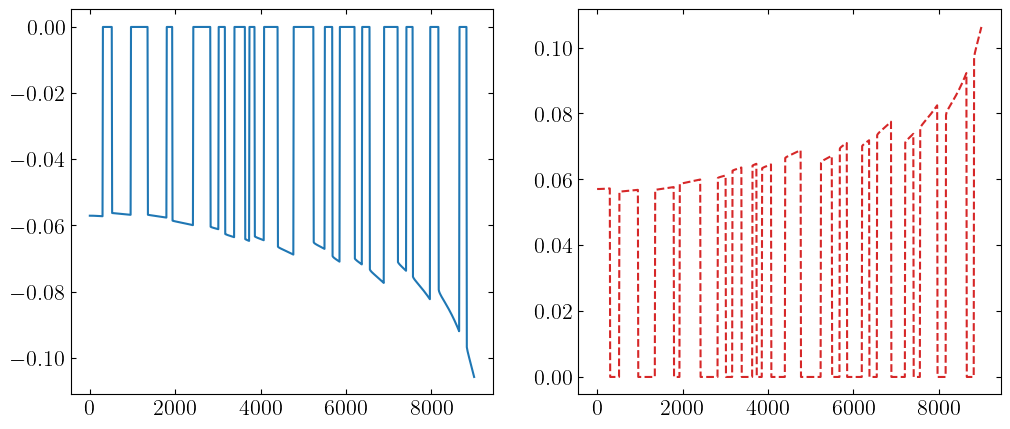

In [116]:
print(params['Positive electrode exchange-current density [A.m-2]'])

#plt.plot(t,sol.observe(model.variables['Positive particle surface concentration [mol.m-3]'])(t)[-1,:],color = 'tab:blue')
f,(ax,ax1) = plt.subplots(1,2,figsize = (12,5))
ax.plot(t,sol.observe(model.variables['X-averaged reaction overpotential [V]'])(t),color = 'tab:blue')
ax1.plot(t,SPM_eqs.eta_r(I,cp,cn,params),color = 'tab:red',ls = '--')

In [119]:
def eta_r(i,cp,cn, params, jn0 = jn0_true,jp0 = jp0_true, K = [0.05,0.2]):
    Ln = params['Negative electrode thickness [m]']
    Lp = params['Positive electrode thickness [m]']
    A = params['Electrode height [m]'] * params['Electrode width [m]']
    Rk = params['Negative particle radius [m]']
    en = params['Negative electrode active material volume fraction']
    ep = params['Positive electrode active material volume fraction']
    ap = 3 * ep / Rk
    an = 3 * en / Rk
    T = params['Initial temperature [K]']
    
    R = sc.R
    F = sc.physical_constants['Faraday constant'][0]
    #jp0 = exchange_current_dens(cp,k = 'p',K=K)
    #jn0 = exchange_current_dens(cn,k = 'n',K=K)

    #i_app = i / A
    #jn = i_app / Ln
    #jp = i_app / Lp
    alpha_p = 0.5
    alpha_n = 0.5
    e = R*T/F *( (1/alpha_p) * np.arcsinh(i / (2 * ap * A *Lp*jp0)) - (1/alpha_n) * np.arcsinh(-i / (2 * an * A *Ln*jn0)))
    return e #(2 * R * T / F) * (np.arcsinh(jn/jn0) -  np.arcsinh(jp/(jp0)))

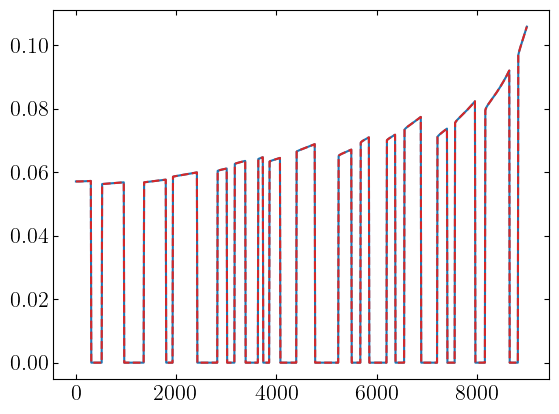

In [121]:
plt.plot(t, eta_r(I,cp,cn,params),color = 'tab:blue')
plt.plot(t,-sol.observe(model.variables['X-averaged reaction overpotential [V]'])(t),color = 'tab:red',ls = '--')

### Let's go with the $j_{k,0}$

In [61]:
def old_exchange_current_dens(c,k=None,K = [5,2]):
    c_reduced = c / np.max(c)
    a = 0.5
    return (c_reduced * (1-c_reduced)) ** (1 - a)

def exchange_current_dens(cn,cp,params, kn=2e-5,kp=6e-7):
    ce = params['Initial concentration in electrolyte [mol.m-3]']
    cn_max = params['Maximum concentration in negative electrode [mol.m-3]']
    cp_max = params['Maximum concentration in positive electrode [mol.m-3]']
    jn0 = kn * np.sqrt(ce * cn * (cn_max-cn)) 
    jp0 = kp * np.sqrt(ce * cp * (cp_max-cp))
    return jn0, jp0 

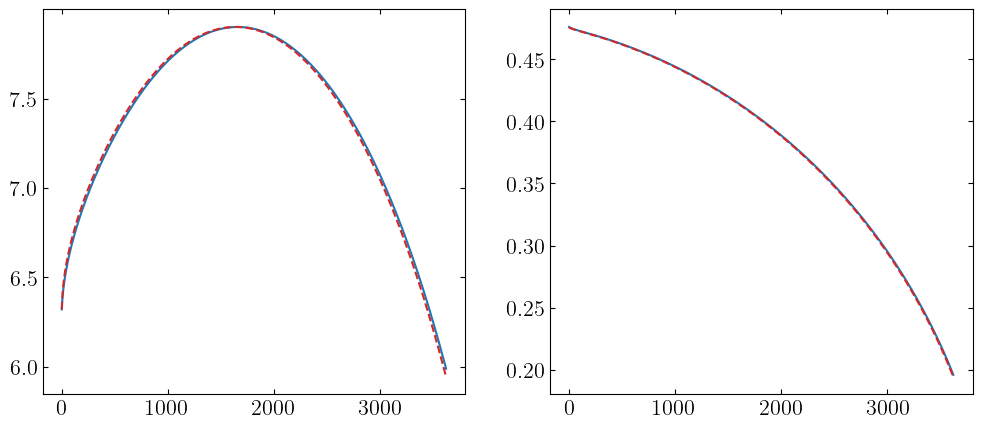

In [71]:
Jn, Jp = exchange_current_dens(cn,cp,params)
f,ax = plt.subplots(1,2,figsize = (12,5))

ax[0].plot(t,Jn,color = 'tab:blue')
ax[0].plot(t,jn0_true,color = 'tab:red',ls = '--')
ax[1].plot(t,Jp,color = 'tab:blue')
ax[1].plot(t,jp0_true,color = 'tab:red',ls = '--')



### Putting it together

(3.55, 3.9)

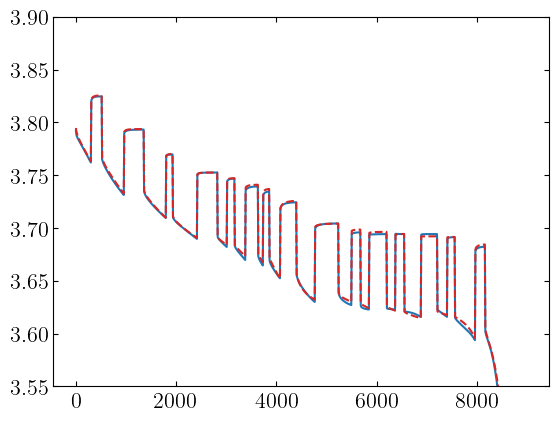

In [113]:

plt.plot(t,SPM_eqs.V_terminal(I,cp,cn,params))
plt.plot(t,V_true,color ='tab:red',ls = '--')
plt.ylim(3.55,3.9)

In [83]:
def gen_data(batches):
    I_vals = np.zeros((batches,1,1000))
    V_vals = np.zeros((batches,1,1000))
    c_vals = np.zeros((batches,2,1000))
    for batch in trange(batches):        
        if batch < int(0.85 * batches):
            sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
        else: 
            sol, model,params = sim_PyBaMM.simulate(np.random.uniform(0.05,2.0))
        
        t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
        V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
        I = sol.observe(model.variables['Current [A]'])(t)
        cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
        cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]

        I_vals[batch,0,:] = I
        V_vals[batch,0,:] = V_true
        c_vals[batch,0,:] = cn
        c_vals[batch,1,:] = cp
    return I_vals,V_vals,c_vals

In [86]:
I_data, V_data, c_data = gen_data(100)

 21%|██        | 21/100 [00:21<01:14,  1.07it/s]2026-02-20 15:12:33.680 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 0.7440217732829694C for 667 seconds'. The returned solution only contains up to step 1 of cycle 27. 
 23%|██▎       | 23/100 [00:23<01:15,  1.02it/s]2026-02-20 15:12:35.761 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 0.7674429069123406C for 315 seconds'. The returned solution only contains up to step 1 of cycle 33. 
 30%|███       | 30/100 [00:29<01:01,  1.13it/s]2026-02-20 15:12:42.273 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 0.7500222717053281C for 450 seconds'. The returned solution only contains up to step 1 of cycle 29. 
 36%|███▌      | 36/100 [

In [93]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

test_size = 0.1
N = len(I_data)
I_test = I_data[0:int(test_size * N),:,:]; c_test = c_data[0:int(test_size * N),:,:]; V_test = V_data[0:int(test_size * N),:,:]
I_train = I_data[int(test_size * N):,:,:]; c_train = c_data[int(test_size * N):,:,:]; V_train = V_data[int(test_size * N):,:,:]

In [94]:
print(I_train.shape, V_train.shape, c_train.shape)

(90, 1, 1000) (90, 1, 1000) (90, 2, 1000)


In [1]:

from neuralop.models import FNO
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         
    hidden_channels=64, 
    in_channels=1,      
    out_channels=2,     
)

from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32), 
                        torch.tensor(V_train, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
                        

NameError: name 'I_train' is not defined

In [179]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  
            c_pred = model(u_batch)
            cn = c_pred[:,0,:]
            cp = c_pred[:,1,:]
            I = u_batch[:,0,:]
            V_pred = SPM_eqs.V_terminal(I,cp,cn,params)
            loss = loss_fn(V_pred, y_batch)
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [180]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 275.6551 ETA: 3:04
Epoch 2 average loss: 242.2729 ETA: 2:53
Epoch 3 average loss: 299.0080 ETA: 2:55
Epoch 4 average loss: 333.5896 ETA: 3:41
Epoch 5 average loss: 712.9044 ETA: 2:55
Epoch 6 average loss: 644.5788 ETA: 2:49
Epoch 7 average loss: 240.2889 ETA: 2:54
Epoch 8 average loss: 234.8300 ETA: 3:07
Epoch 9 average loss: 245.9873 ETA: 2:34
Epoch 10 average loss: 249.2940 ETA: 2:32
Epoch 11 average loss: 235.7123 ETA: 2:31
Epoch 12 average loss: 249.1693 ETA: 2:21
Epoch 13 average loss: 249.4100 ETA: 2:14
Epoch 14 average loss: 250.7824 ETA: 2:11
Epoch 15 average loss: 253.7795 ETA: 2:07
Epoch 16 average loss: 252.1650 ETA: 2:03
Epoch 17 average loss: 236.5727 ETA: 2:16
Epoch 18 average loss: 248.7680 ETA: 2:03
Epoch 19 average loss: 252.5796 ETA: 2:06
Epoch 20 average loss: 248.8373 ETA: 1:51
Epoch 21 average loss: 251.8820 ETA: 1:45
Epoch 22 average loss: 251.3572 ETA: 1:48
Epoch 23 average loss: 239.0449 ETA: 1:40
Epoch 24 average loss: 250.8924 ETA: 1:35
E

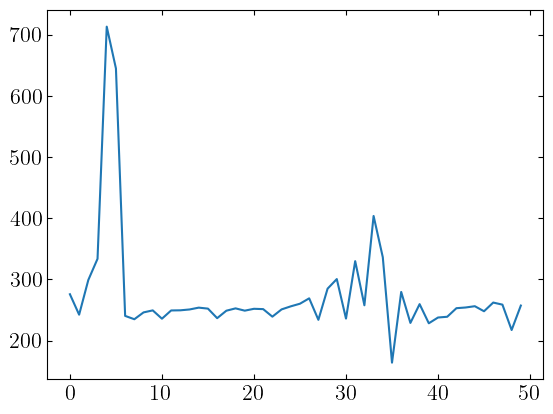

In [181]:
plt.plot(history['loss'])

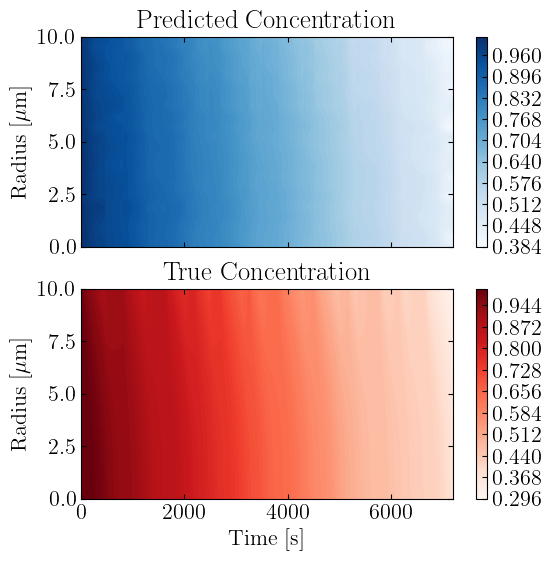

In [410]:
test = 5
i = I_test[test,0,:].reshape(1, 1, 1000) 
c_t = cn_test[test,:,:].reshape(1, 22, 1000)

#print(i.shape, v.shape)
c_pred = model(torch.tensor(i, dtype=torch.float32)).detach().numpy()
f, ax = plt.subplots(2,1,figsize=(6,6), sharex=True)
#f.subplots_adjust(hspace=0.05)¨


ax[0].contourf(T,R,c_pred[0,...],levels = 100, cmap='Blues', label='Predicted')
ax[1].contourf(T,R,c_t[0,...],levels = 100, cmap='Reds', label ='True')
ax[1].set_xlabel('Time [s]')
ax[0].set_ylabel('Radius [$\mu$m]')
ax[1].set_ylabel('Radius [$\mu$m]')
ax[0].set_title('Predicted Concentration')
ax[1].set_title('True Concentration')

#ax[1].contourf(T,R,c_t[0,...] - c_pred[0,...],levels = 100, cmap='coolwarm')
cb = plt.colorbar(ax[1].collections[0], ax=ax[1], orientation='vertical')
cb = plt.colorbar(ax[0].collections[0], ax=ax[0], orientation='vertical')
#plt.savefig('figs_NO/NO_concentration.pdf', bbox_inches='tight')

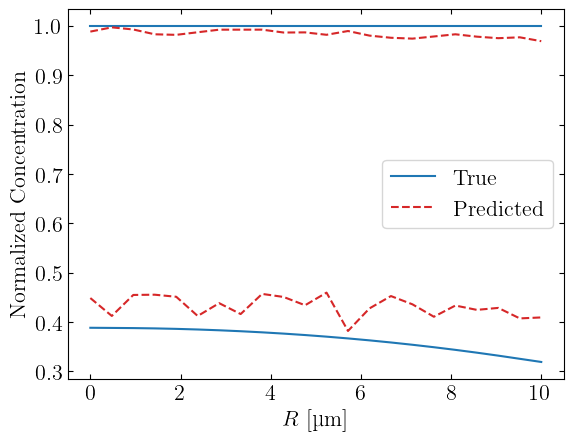

In [391]:

plt.plot(np.linspace(0,10,22), c_t[0,:,0], label='True', color='tab:blue')
plt.plot(np.linspace(0,10,22), c_pred[0,:,0].detach().numpy(), label='Predicted', color='tab:red', linestyle='--')
plt.plot(np.linspace(0,10,22), c_t[0,:,-1], color='tab:blue')
plt.plot(np.linspace(0,10,22), c_pred[0,:,-1].detach().numpy(), color='tab:red', linestyle='--')

plt.xlabel('$R$ [µm]')
plt.ylabel('Normalized Concentration')
plt.legend()

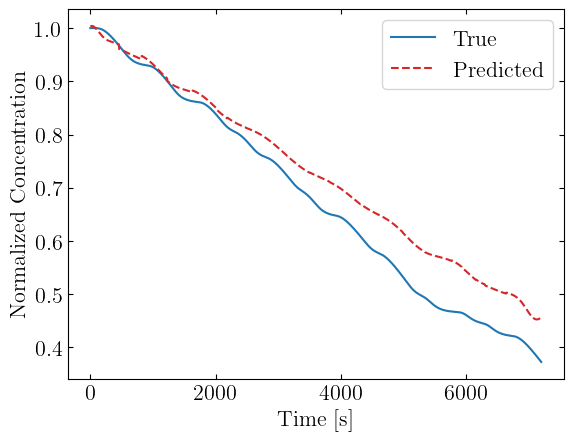

In [ ]:
plt.plot(t, np.mean(c_t[:,0,:],axis =0), label='True', color='tab:blue')
plt.plot(t, np.mean(c_pred[:,0,:],axis = 0), label='Predicted', color='tab:red', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Normalized Concentration')
plt.legend()
#plt.savefig('figs_NO/NO_R_avg_concentration_time.pdf', bbox_inches='tight')
